# 03 — Wax Stores Weight

Wax gets his ironmind (`sim/feruchemy.py`). The model, briefly:

- **Three states, one dial**: storing, tapping, or neither. While storing at
  fraction 0.5 he *is* half his mass, continuously — the deficit flows into the
  ironmind as kilogram-seconds. Zero-sum: what flows in is exactly what can
  flow back out (Compounding, which breaks this, waits for Miles).
- **Iron stores mass, not gravity** (Word of Brandon), and **momentum is
  conserved when mass changes**: `Body.change_mass` scales velocity by
  old/new. That one line is where all of today's strangeness comes from.

Three experiments:

- **A.** Same coin, lighter Wax — does storing weight raise the hover ceiling?
  (Single-knob sweep over store fraction.)
- **B.** The momentum jolt — store mid-fall, then stop, and watch what
  conservation of momentum does to a falling lawman.
- **C.** Land like artillery — same launch, three landing styles, compared by
  impact momentum and energy.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import matplotlib.pyplot as plt

from sim import Body, World, Steelpush, IronFeruchemy, GRAVITY_M_PER_S2, plot_heights

WAX_BASE_MASS_KG = 80
COIN_MASS_KG = 0.004
PUSH_STRENGTH_N = 2000
PUSH_RANGE_M = 16

## Experiment A — storing weight raises the hover ceiling

Notebook 02 found the hover equilibrium $d_{eq} = R\,(1 - mg/S)$. Nothing in
that formula knows about feruchemy — but $m$ is in it, so a Wax who stores
weight should ride the *same coin* with the *same push* to a higher ceiling.
One knob (store fraction), three values, everything else held fixed.

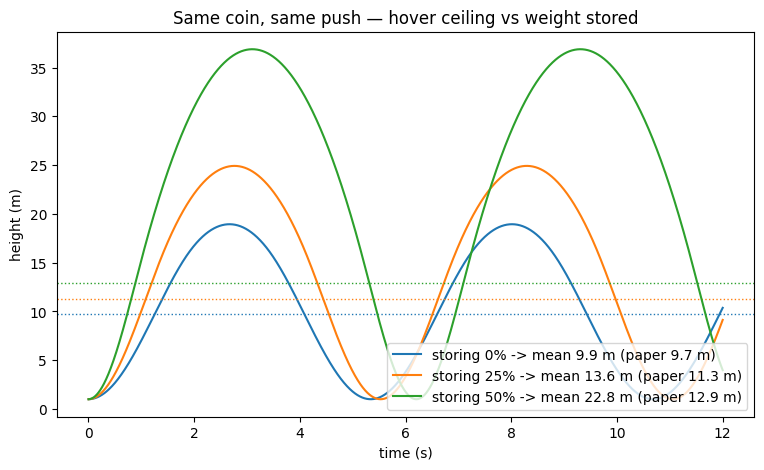

In [2]:
figure, ax = plt.subplots(figsize=(9, 5))

for store_fraction in [0.0, 0.25, 0.5]:
    world = World()
    coin = world.add_body(Body("coin", COIN_MASS_KG, (0, 0.01), radius_m=0.01, is_metal=True))
    wax = world.add_body(Body("wax", WAX_BASE_MASS_KG, (0, 1.0)))
    ironmind = world.add_power(IronFeruchemy(wax))
    push = world.add_power(Steelpush(wax, coin, PUSH_STRENGTH_N, PUSH_RANGE_M))
    ironmind.store(store_fraction)
    push.active = True
    world.run(12.0)

    effective_mass = WAX_BASE_MASS_KG * (1 - store_fraction)
    paper_ceiling = PUSH_RANGE_M * (1 - effective_mass * GRAVITY_M_PER_S2 / PUSH_STRENGTH_N) + 0.01
    data = world.history.body("wax")
    late_mean = data["y"][len(data["y"]) // 2:].mean()
    line, = ax.plot(data["t"], data["y"],
                    label=f"storing {store_fraction:.0%} -> mean {late_mean:.1f} m (paper {paper_ceiling:.1f} m)")
    ax.axhline(paper_ceiling, color=line.get_color(), linestyle=":", linewidth=1)

ax.set_xlabel("time (s)")
ax.set_ylabel("height (m)")
ax.set_title("Same coin, same push — hover ceiling vs weight stored")
ax.legend(loc="lower right")
plt.show()

## Experiment B — the momentum jolt

The counterintuitive one. Momentum $p = mv$ is conserved through a mass change,
so **storing weight mid-fall makes you fall *faster***: halve the mass and the
same momentum drives half the freight at twice the speed. Stop storing and the
mass snaps back, halving your speed again.

Wax steps off a 200 m ledge. At t = 2 s he stores half his weight; at t = 3 s
he stops. Watch the velocity trace.

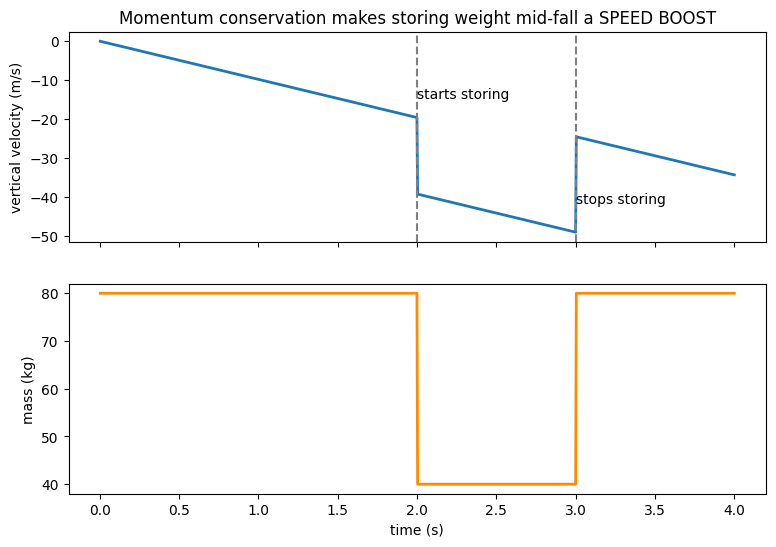

just before storing:  -19.6 m/s
just after storing:   -39.3 m/s
just before stopping: -49.0 m/s
just after stopping:  -24.6 m/s


In [3]:
world = World()
wax = world.add_body(Body("wax", WAX_BASE_MASS_KG, (0, 200)))
ironmind = world.add_power(IronFeruchemy(wax))

world.run(2.0)
ironmind.store(0.5)   # mass 80 -> 40: speed doubles
world.run(1.0)
ironmind.stop()       # mass 40 -> 80: speed halves
world.run(1.0)

data = world.history.body("wax")
figure, (ax_v, ax_m) = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
ax_v.plot(data["t"], data["vy"], linewidth=2)
ax_v.axvline(2.0, color="gray", linestyle="--"); ax_v.axvline(3.0, color="gray", linestyle="--")
ax_v.annotate("starts storing", (2.0, data["vy"].min() * 0.3))
ax_v.annotate("stops storing", (3.0, data["vy"].min() * 0.85))
ax_v.set_ylabel("vertical velocity (m/s)")
ax_v.set_title("Momentum conservation makes storing weight mid-fall a SPEED BOOST")
ax_m.plot(data["t"], data["mass"], color="darkorange", linewidth=2)
ax_m.set_ylabel("mass (kg)")
ax_m.set_xlabel("time (s)")
plt.show()

ticks_per_second = 240
print(f"just before storing: {data['vy'][2 * ticks_per_second - 1]:6.1f} m/s")
print(f"just after storing:  {data['vy'][2 * ticks_per_second + 1]:6.1f} m/s")
print(f"just before stopping:{data['vy'][3 * ticks_per_second - 1]:6.1f} m/s")
print(f"just after stopping: {data['vy'][3 * ticks_per_second + 1]:6.1f} m/s")

So a Skimmer who panics mid-fall and dumps weight has made things *worse* —
twice the speed, and on hitting the ground at base mass he'd... well, that's
Experiment C's question. Note this is a direct consequence of the canon
momentum ruling; a velocity-conserving model would show a flat line here.
(Canon also says a mass-storing Skimmer falls safely because air resistance
matters more at low mass — our world has no air yet, which is exactly why the
raw momentum effect is visible in pure form.)

## Experiment C — land like artillery

Identical coin-launch for three Waxes (push cuts off at apex; ironmind
pre-banked from a morning of storing). What differs is the descent:

1. **Baseline** — falls at base mass.
2. **Tap at apex** — doubles his mass for the whole descent.
3. **Tap at the last moment** — doubles his mass at 5 m up.

Impact punch is measured as momentum (how hard you are to stop) and kinetic
energy (how much wreckage you make).

In [4]:
def launch_and_land(landing_style):
    world = World()
    coin = world.add_body(Body("coin", COIN_MASS_KG, (0, 0.01), radius_m=0.01, is_metal=True))
    wax = world.add_body(Body("wax", WAX_BASE_MASS_KG, (0, 1.0)))
    ironmind = world.add_power(IronFeruchemy(wax, initial_reserve_kg_seconds=600))
    push = world.add_power(Steelpush(wax, coin, PUSH_STRENGTH_N, PUSH_RANGE_M))
    push.active = True

    while wax.velocity[1] >= 0 or not push.active:  # rise until apex
        world.step()
        if wax.velocity[1] < 0 and push.active:
            push.active = False  # cut the push at apex for a clean fall
            apex_height = wax.position[1]
            if landing_style == "tap at apex":
                ironmind.tap(1.0)
            break

    while not wax.on_ground:
        if landing_style == "tap at last moment" and wax.position[1] < 5.0 and ironmind.tap_fraction == 0:
            ironmind.tap(1.0)
        impact_mass, impact_speed = wax.mass_kg, abs(wax.velocity[1])
        world.step()
    return apex_height, impact_mass, impact_speed

print(f"{'landing style':22s} {'apex':>7s} {'speed':>9s} {'mass':>7s} {'momentum':>10s} {'energy':>9s}")
for style in ["baseline", "tap at apex", "tap at last moment"]:
    apex, mass, speed = launch_and_land(style)
    momentum = mass * speed
    energy_kj = 0.5 * mass * speed**2 / 1000
    print(f"{style:22s} {apex:5.1f} m {speed:6.1f} m/s {mass:4.0f} kg {momentum:7.0f} kg*m/s {energy_kj:6.1f} kJ")

landing style             apex     speed    mass   momentum    energy
baseline                18.9 m   19.1 m/s   80 kg    1526 kg*m/s   14.6 kJ
tap at apex             18.9 m   19.1 m/s  160 kg    3057 kg*m/s   29.2 kJ
tap at last moment      18.9 m   12.6 m/s  160 kg    2017 kg*m/s   12.7 kJ


## Findings

1. **Storing weight raises the hover ceiling**, sim matching paper at every
   store fraction — "it's easier to fly when storing weight" emerges from
   F = ma, uncoded.
2. **Storing mid-fall is a speed boost** (momentum conservation), which is
   both canon-derived and deeply weird. The velocity trace doubles and halves
   on command like a square wave riding a gravity ramp.
3. **Tapping weight is a landing weapon.** Tap at apex and you arrive with
   roughly double the momentum *and* double the energy of baseline. Tap at
   the last moment and you arrive *slower* but with comparable momentum —
   harder to stop, less self-shattering. Wax's meteor landings check out.
4. **Next (04):** Wayne — gold feruchemy (healing, and being sickly while
   storing), then bendalloy bubbles, then the emergence test: fast healing
   from normal-rate healing inside compressed time, with zero Wayne-specific
   code.